In [1]:
%pip -q install torchgeo scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.4/811.4 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import drive
drive.mount('/content/drive') # for saving model
# colab is slow for small files in a mounted drive, this copies it to a local colab disk
!cp "/content/drive/My Drive/Dissertation/Datasets/ETCI2021_filtered_40pct.zip" "/content/ETCI2021_filtered_40pct.zip"

# Unzip it locally (quietly)
!unzip -q -o "/content/ETCI2021_filtered_40pct.zip" -d "/content/ETCI2021_filtered_40pct"

Mounted at /content/drive


In [3]:
import math
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path
from glob import glob
from tqdm import tqdm
import torch
import tensorflow as tf
import h5py

folder_models = ('/content/drive/My Drive/Dissertation/models/')
DS_ROOT = Path('/content/ETCI2021_filtered_40pct/ETCI2021_filtered_40pct/data/') #unzipped so nested folder
if not DS_ROOT.exists():
  raise FileNotFoundError("Couldn't find copied dataset")

# Referenced from: https://medium.com/cloud-to-street/jumpstart-your-machine-learning-satellite-competition-submission-2443b40d0a5a

In [4]:
# Nabbed from sarpyx: https://github.com/ESA-PhiLab/sarpyx/blob/main/sarpyx/utils/rfigen.py
from scipy.constants import c

def freq2wavelen(f_hz):
    return c / f_hz

def fspl(r_m, wavelen_m):
    return (4 * np.pi * r_m / wavelen_m) ** 2

def GenerateRFISignal(sqd, RadPar=None, verbose=False):
    """Generate Radio Frequency Interference (RFI) signal for SAR data.

    Args:
        sqd (np.ndarray): Input SAR single look complex data with shape (rows, cols).
        RadPar (dict): Radar parameters containing:
            - 'bw': Bandwidth in Hz
            - 'fo': Center frequency in Hz
            - 'fs': Sampling frequency in Hz

    Returns:
        tuple: A tuple containing:
            - sInterf (np.ndarray): Generated interference signal with same shape as sqd
            - IR (dict): Dictionary containing RFI parameters used in generation
    """


    if sqd is None:
        raise ValueError('The parameter "sqd" must be a valid numpy ndarray.')

    if isinstance(sqd, torch.Tensor): # MB:added torch instance check for conversions
      sqd = sqd.cpu().numpy()

    RadPar = {
            'fo': 5405000454.33435,
            'fs': 64345238.12571428,
            'bw': 56504455.48389234,
            'ts': 1.554116558005821e-08
    } if RadPar is None else RadPar


    IR = {}

    # === RFI Physical Parameters ===
    IR['freqShift'] = (np.random.rand() - 0.5) * RadPar['bw']  # shift within radar BW
    IR['fc'] = RadPar['fo'] + IR['freqShift']
    IR['SIR_dB'] = np.random.uniform(-25, -5)  # control strength
    IR['bw'] = np.random.uniform(0.005, 0.05) * RadPar['bw']  # narrower than radar BW
    IR['PRF'] = np.random.randint(1000, 2000)
    IR['duty'] = np.random.uniform(0.1, 0.5)  # sparse duty
    IR['Gain'] = 1.0
    IR['Lambda'] = freq2wavelen(IR['fc'])
    IR['T'] = IR['duty'] / IR['PRF']
    IR['K'] = IR['bw'] / IR['T']
    fs = RadPar['fs']
    IR['t'] = np.arange(-IR['T']/2, IR['T']/2, 1/fs)

    # === Chirp Pulse Generation ===
    chirp = np.exp(1j * np.pi * IR['K'] * IR['t']**2)
    chirp *= np.exp(1j * 2 * np.pi * IR['freqShift'] * IR['t'])  # center-shift
    chirp *= np.hanning(len(chirp))  # envelope
    chirp /= np.max(np.abs(chirp))

    # === Pulse Train (1D) ===
    rows, cols = sqd.shape
    burst_duration = rows / IR['PRF']
    IRstream_len = int(burst_duration * fs)
    pulse_spacing = int(fs / IR['PRF'])
    pulse_len = len(chirp)
    IRstream = np.zeros(IRstream_len, dtype=np.complex64)

    pulse_indices = np.arange(0, IRstream_len - pulse_len, pulse_spacing)
    N_total = len(pulse_indices)
    N_active = int(IR['duty'] * N_total)
    active_idx = np.random.choice(pulse_indices, N_active, replace=False)
    for idx in active_idx:
        IRstream[idx:idx+pulse_len] += chirp

    # === Map to Burst Grid (Spatial Submask) ===
    IRmap = np.zeros((rows, cols), dtype=np.complex64)
    # Random RFI spatial extent (5-95% of image dimensions)
    az_fraction = np.random.uniform(0.05, 0.95)
    rg_fraction = np.random.uniform(0.05, 0.95)
    sub_rows = int(rows * az_fraction)
    sub_cols = int(cols * rg_fraction)

    # Random position ensuring no border overflow
    az_start = np.random.randint(0, max(1, rows - sub_rows + 1))
    az_stop = az_start + sub_rows
    rg_start = np.random.randint(0, max(1, cols - sub_cols + 1))
    rg_stop = rg_start + sub_cols

    # reshape with tiling
    IRstream_crop = IRstream[:sub_rows * sub_cols]
    IRmap[az_start:az_stop, rg_start:rg_stop] = IRstream_crop.reshape((sub_rows, sub_cols))

    # === Power Calibration ===
    signal_power_lin = np.mean(np.abs(sqd)**2)
    signal_power_dB = 10 * np.log10(signal_power_lin + 1e-6) # MB: added 1e-6 to prevent div 0
    PrRFI_dB = signal_power_dB - IR['SIR_dB']
    PrRFI = 10 ** (PrRFI_dB / 10)
    sInterf = IRmap * np.sqrt(PrRFI)

    # === Metadata & Logging ===
    IR['AffectedAz'] = (az_start, az_stop)
    IR['AffectedRg'] = (rg_start, rg_stop)
    if verbose:
        print(f"[INFO] Injected RFI: freq offset = {IR['freqShift']/1e6:.2f} MHz, bw = {IR['bw']/1e6:.2f} MHz")
        print(f"[INFO] SIR = {IR['SIR_dB']} dB, Affected area: Az[{az_start}:{az_stop}], Rg[{rg_start}:{rg_stop}]")

    return sInterf, IR


def plot_dual_pol_sar_grayscale(sar_tensor, show_image=True):
    """
    Display dual-polarisation SAR data (VV and VH) as a grayscale image.

    Expected shapes:
        (2, H, W)
    or:
        (H, W, 2)
    """

    # Convert PyTorch tensor to NumPy
    if isinstance(sar_tensor, torch.Tensor):
        sar = sar_tensor.detach().cpu().numpy()
    else:
        sar = np.asarray(sar_tensor)

    # Extract VV and VH
    if sar.ndim != 3:
        raise ValueError(
            f"Expected a 3D SAR array, got shape {sar.shape}"
        )

    if sar.shape[0] == 2:
        # Channel-first: (2, H, W)
        vv = sar[0]
        vh = sar[1]

    elif sar.shape[-1] == 2:
        # Channel-last: (H, W, 2)
        vv = sar[:, :, 0]
        vh = sar[:, :, 1]

    else:
        raise ValueError(
            f"Expected 2 channels (VV and VH), got shape {sar.shape}"
        )

    # Combine VV and VH directly
    gray_image = (vv + vh) / 2.0

    # Display
    if show_image:
        plt.figure(figsize=(6, 6))
        plt.imshow(gray_image, cmap="gray")
        plt.title("Dual-Polarisation SAR Grayscale")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return gray_image


**Setup dataframes**

In [5]:
def concatenate_SAR(vv_path, vh_path):
    vv_img = cv2.imread(vv_path, cv2.IMREAD_GRAYSCALE)
    vh_img = cv2.imread(vh_path, cv2.IMREAD_GRAYSCALE)
    # ratio = vv_img - vh_img
    if vv_img is  None:
        raise FileExistsError(f"Could not open vv file with path {vv_path}")
    if vh_img is None:
        raise FileExistsError(f"Could not open vh file with path {vh_path}")

    concatenated_SAR = np.stack((vv_img, vh_img), axis=-1)
    if concatenated_SAR.shape != (*vv_img.shape, 2):
        raise ValueError("Final concatenated image shape mismatch.")
    return concatenated_SAR

def append_ratio(dataset):
    """
    Add a third channel representing VV - VH.

    Expected input:
        (N, 256, 256, 2)

    Returns:
        (N, 256, 256, 3)
    """

    dataset = np.asarray(dataset, dtype=np.float32)

    # Check input dimensions
    if dataset.ndim != 4:
        raise ValueError(
            f"Expected dataset with 4 dimensions (N, H, W, C), "
            f"but got shape {dataset.shape}"
        )

    if dataset.shape[-1] != 2:
        raise ValueError(
            f"Expected 2 input channels (VV, VH), "
            f"but got {dataset.shape[-1]}"
        )

    # Extract VV and VH
    vv = dataset[..., 0]
    vh = dataset[..., 1]

    # Calculate ratio/difference channel
    ratio = vv - vh

    # Add channel dimension back
    ratio = ratio[..., np.newaxis]

    # Concatenate: VV, VH, ratio
    dataset_with_ratio = np.concatenate(
        [dataset, ratio],
        axis=-1
    )

    # Final validation
    if dataset_with_ratio.shape[-1] != 3:
        raise ValueError(
            f"Expected 3 channels after adding ratio, "
            f"but got shape {dataset_with_ratio.shape}"
        )

    return np.ascontiguousarray(dataset_with_ratio, dtype=np.float32)

def find_vv(flood_label_path: Path) -> Path:
    file_name = flood_label_path.name
    vv_path = flood_label_path.parent.parent / "vv" / file_name
    vv_path = vv_path.with_name(f"{vv_path.stem}_vv{vv_path.suffix}")
    if vv_path.exists():
        return vv_path
    else:
        print(vv_path)
        raise FileNotFoundError(f"Couldn't find vv file for {flood_label_path}")

def find_vh(flood_label_path: Path) -> Path:
    file_name = flood_label_path.name
    vh_path = flood_label_path.parent.parent / "vh" / file_name
    vh_path = vh_path.with_name(f"{vh_path.stem}_vh{vh_path.suffix}")
    if vh_path.exists():
        return vh_path
    else:
        print(vh_path)
        raise FileNotFoundError(f"Couldn't find vh file for {flood_label_path}")

def fetch_train_test_data_from_split(ds_root, split):
    X = []
    Y = []
    if split not in ["train", "test"]:
      raise ValueError("Split needs to be train or test")
    split_path = ds_root / split
    if not split_path.exists():
        return None, None

    all_flood_labels = list(split_path.glob("*/tiles/flood_label/*.png"))
    print(f"Processing {len(all_flood_labels)} images for {split}ing split...")

    for flood_label in tqdm(all_flood_labels):
        try:
            vv_path = find_vv(flood_label)
            vh_path = find_vh(flood_label)
            fl_img = cv2.imread(str(flood_label), cv2.IMREAD_GRAYSCALE)
            SAR_img = concatenate_SAR(vv_path, vh_path)
            X.append(SAR_img)
            Y.append(fl_img)

        except (FileNotFoundError, FileExistsError) as e:
            continue #maybe something else
    return X, Y


LOAD_PREPROCESSED_DATA = True

if not LOAD_PREPROCESSED_DATA:
  X_Train, Y_Train = fetch_train_test_data_from_split(DS_ROOT, "train")
  if X_Train is None or Y_Train is None:
    print("Arrays have not been populated, likely due to a path error")
  # X: (256, 256, 3)
  # Y: (256, 256, 1)
else:
  with h5py.File('/content/drive/My Drive/Dissertation/Datasets/ETCI2021_40_pct_preprocessed_noRFI.h5', 'r') as f:
    X_Train = f['X_Train'][:]
    Y_Train = f['Y_Train'][:]
    X_Train_min = f.attrs["X_Train_min"]
    X_Train_max = f.attrs["X_Train_max"]
    f.close()

# print(X_Train.shape)


In [6]:
normalise_Y = lambda t: t.astype('float32') / np.max(t) # scale to [0, 1]

from scipy.ndimage import uniform_filter
def LeeFilter(img, window_size: int = 2, noise_variance: float = 0.001): # was window=5, noise = 0.01
    # img = img_tensor.numpy()
    size = (window_size, window_size, 1)#(1, window_size, window_size)

    # 1. Compute local statistics
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2

    # 2. True Lee Filter Weighting Formula
    # k = Var(x) / Var(y) where Var(x) = (Var(y) - mean^2 * noise_var) / (1 + noise_var)
    # To keep it safe from negatives, we clip at 0
    img_true_var = (img_variance - (img_mean**2) * noise_variance) / (1 + noise_variance)
    img_true_var = np.clip(img_true_var, 0, None)

    img_weights = img_true_var / (img_variance + 1e-8)

    # 3. Linear combination
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output

def calc_subset_min_max(dataset_np):
    all_mins = []
    all_maxs = []

    for sample in dataset_np:
      all_mins.append(np.min(sample))
      all_maxs.append(np.max(sample))

    # The true global min is the minimum of all sample mins
    global_min = float(np.min(all_mins))
    # The true global max is the maximum of all sample maxs
    global_max = float(np.max(all_maxs))

    return global_min, global_max


def normalise_0_1_single_samples(dataset_sample, global_min, global_max):
    # Min-Max Formula: (x - min) / (max - min)
    # Added 1e-6 to prevent division by zero if max == min
    sample = (dataset_sample - global_min) / (global_max - global_min + 1e-6)

    return sample


def normalise_0_1(dataset_np, global_min=None, global_max=None):

    if global_min is None or global_max is None:
        global_min, global_max = calc_subset_min_max(dataset_np)

    # Min-Max Formula: (x - min) / (max - min)
    # Added 1e-6 to prevent division by zero if max == min
    dataset_np = [(tensor - global_min) / (global_max - global_min + 1e-6) for tensor in dataset_np]

    return dataset_np, global_min, global_max

def unnormalise(norm_samples, global_min, global_max):
  if not isinstance(norm_samples, (list, tuple)):
    norm_samples = [norm_samples]
  unnorm_samples = [(sample * (global_max - global_min + 1e-6)) + global_min for sample in norm_samples]
  return unnorm_samples

def add_RFI(X):
  # X is a np array of samples, should have 2 channels
  if X.shape[-1] != 2:
    print(X.shape)
    raise IndexError("Subset has wrong dimensions")

  X_RFI = []
  VV_IR_dicts = []
  VH_IR_dicts = []
  for sample in X:
    sample = sample.astype(np.float32, copy=True)
    signal_VV, IR_dict_VV = GenerateRFISignal(sample[:, :, 0], verbose=False)
    signal_VH, IR_dict_VH = GenerateRFISignal(sample[:, :, 1], verbose=False)
    sample[:, :, 0] += abs(signal_VV)
    sample[:, :, 1] += abs(signal_VH)
    X_RFI.append(sample)
    VV_IR_dicts.append(IR_dict_VV)
    VH_IR_dicts.append(IR_dict_VH)

  return X_RFI, VV_IR_dicts, VH_IR_dicts

# def preprocess_raw_X(X, add_rfi=False):
#   """Returns preprocessed X array, min of X, max of X"""
#   X = np.array(X)
#   if add_rfi:
#     X = add_RFI(X)
#   X_min, X_max = calc_subset_min_max(X)
#   X, _, _ = normalise_0_1(X, X_min, X_max)
#   X = np.array(X)
#   return X, X_min, X_max



# RFI test

# sample = X_Train[20].copy()
# sample_y = Y_Train[20].copy()
# img = plot_dual_pol_sar_grayscale(sample[:, :, :2])
# plt.imsave("/content/drive/My Drive/Dissertation/figures/flood_sample_20.png", img)
# sample_y = np.squeeze(sample_y)
# plt.imshow(sample_y, cmap="gray")
# signal_VV, IR_dict_VV = GenerateRFISignal(sample[:, :, 0], verbose=True)
# signal_VH, IR_dict_VH = GenerateRFISignal(sample[:, :, 1], verbose=True)
# sample[:, :, 0] = sample[:, :, 0] + signal_VV
# sample[:, :, 1] = sample[:, :, 1] + signal_VH
# sample[:, :, 2] = sample[:, :, 0] - sample[:, :, 1]
# img = plot_dual_pol_sar_grayscale(sample[:, :, :2])
# plt.imsave("/content/drive/My Drive/Dissertation/figures/flood_sample_20_RFI.png", img)

# Running normalisation functions ===========================
# Reccomended pipeline:
# Add RFI - optional
# Speckle filter?
# scale [0, 1]
ADD_RFI = False
PCT_SAMPLES = 1.0 # set is small enough -> 778
X_Train = X_Train[0:int(len(X_Train) * PCT_SAMPLES)]
Y_Train = Y_Train[0:int(len(Y_Train) * PCT_SAMPLES)]

if not LOAD_PREPROCESSED_DATA:
  print(f"Preprocessing {len(X_Train)} training samples")
  X_Train = np.array(X_Train)
  X_Train_min, X_Train_max = calc_subset_min_max(X_Train)
  X_Train_processed = []
  for sample in tqdm(X_Train, desc="training samples"):
    if ADD_RFI:
      signal_VV, IR_dict_VV = GenerateRFISignal(sample[:, :, 0], verbose=False)
      signal_VH, IR_dict_VH = GenerateRFISignal(sample[:, :, 1], verbose=False)
      sample[:, :, 0] = sample[:, :, 0] + signal_VV
      sample[:, :, 1] = sample[:, :, 1] + signal_VH
    sample = normalise_0_1_single_samples(sample, X_Train_min, X_Train_max)
    X_Train_processed.append(sample)
  X_Train_processed = np.array(X_Train_processed)



  print(f"Preprocessing {len(Y_Train)} training samples")
  Y_Train_processed = (np.asarray(Y_Train) > 0).astype(np.float32)
  Y_Train_processed = np.array(Y_Train)


  # save data
  print("Writing preprocessed data")
  with h5py.File("/content/drive/My Drive/Dissertation/Datasets/ETCI2021_40_pct_preprocessed_noRFI.h5", 'w') as f:
    f.create_dataset('X_Train', data=X_Train_processed)
    f.create_dataset('Y_Train', data=Y_Train_processed)
    f.attrs["X_Train_min"] = float(X_Train_min)
    f.attrs["X_Train_max"] = float(X_Train_max)
    f.close()

Y_Train = (Y_Train / 255.0).astype(np.float32)

# need to work out class weights
# Check labels
print("Unique Y values:", np.unique(Y_Train))

# Calculate class balance
flood_pixels = np.sum(Y_Train == 1.)
total_pixels = Y_Train.size

pct_flood = flood_pixels / total_pixels

FOCAL_ALPHA = round(1 - pct_flood, 3)
FLOOD_WEIGHT = round((1 - pct_flood) * 10.0, 3)

print(f"Flood pixels: {pct_flood:.3%}")
print(f"Focal alpha: {FOCAL_ALPHA}")
print(f"Flood weight: {FLOOD_WEIGHT}")

Unique Y values: [0. 1.]
Flood pixels: 59.663%
Focal alpha: 0.403
Flood weight: 4.034


In [7]:
# X_Train = X_Train.numpy() # they are already np
# Y_Train = Y_Train.numpy() # they are already np

X_augmented = np.concatenate([
    X_Train,
    np.flip(X_Train, axis=1),
    np.flip(X_Train, axis=2),
    np.rot90(X_Train, axes=(1, 2))
], axis=0)

Y_augmented = np.concatenate([
    Y_Train,
    np.flip(Y_Train, axis=1),
    np.flip(Y_Train, axis=2),
    np.rot90(Y_Train, axes=(1,2))
], axis=0)

X_Train_processed = np.ascontiguousarray(
    X_augmented,
    dtype=np.float32
)

Y_Train_processed = np.ascontiguousarray(
    Y_augmented,
    dtype=np.float32
)

X_Train_processed = append_ratio(X_Train_processed)

print("X:", X_Train_processed.shape)
print("Y:", Y_Train_processed.shape)

X: (1180, 256, 256, 3)
Y: (1180, 256, 256)


# Data preprocessing

# Model

In [8]:
# from keras.models import Model, Sequential
# from keras.layers import Input, Activation, Conv2D, MaxPool2D, BatchNormalization, Dropout, \
# add, UpSampling2D, Concatenate
# from keras.regularizers import l2

# # Some notes
# # Traba had fewer filters per steps and increased bottle neck size?
# # Traba used focal loss, alpha = 0.5, gamma = 2
# L2_STRENGTH = 6e-4# 15:57 02/09 changed frrom 6e-4

# input_shape = (256, 256, 3) # 3 with ratio channel
# main_input = Input(shape=input_shape, name="input")

# # ============
# # ENCODER Path
# # ============

# # Block 1 - Input to 32 filters
# # Main path
# x = Conv2D(16, kernel_size=(3, 3), padding="same")(main_input)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Conv2D(16, kernel_size=(3, 3), padding="same")(x)
# x = BatchNormalization()(x)
# shortcut = Conv2D(16, kernel_size=(1, 1), padding="same")(main_input)
# shortcut = BatchNormalization()(shortcut)
# e1 = add([x, shortcut])
# e1 = Activation('relu')(e1)
# p1 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e1) # down to 32 x 32

# # BLOCK 2 ---------------------------------------------------------------------
# # --- Main Residual Path ---
# # First convolution: extracts features
# x = Conv2D(32, kernel_size=(3, 3), padding="same")(p1)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# # Second convolution: processes features further before addition
# x = Conv2D(32, kernel_size=(3, 3), padding="same")(x)
# x = BatchNormalization()(x)
# # --- Shortcut Path ---
# # Because p1 has 16 channels (from e1) and our target is 32 channels,
# # we use a 1x1 conv to match the dimensions perfectly.
# shortcut = Conv2D(32, kernel_size=(1, 1), padding="same")(p1)
# shortcut = BatchNormalization()(shortcut)
# # --- The Residual Merge ---
# # We add the shortcut back to the main path, THEN apply the final ReLU
# e2 = add([x, shortcut])
# e2 = Activation('relu')(e2)
# p2 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e2) # down to 64 x 64

# # Block 3 - 64 to 128 filters
# x = Conv2D(64, kernel_size=(3, 3), padding="same")(p2)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Conv2D(64, kernel_size=(3, 3), padding="same")(x)
# x = BatchNormalization()(x)
# shortcut = Conv2D(64, kernel_size=(1, 1), padding="same")(p2)
# shortcut = BatchNormalization()(shortcut)
# e3 = add([x, shortcut])
# e3 = Activation('relu')(e3)
# p3 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e3) # down to 32 x 32

# # Block 4
# x = Conv2D(96, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(p3)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Conv2D(96, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(x)
# x = BatchNormalization()(x)
# shortcut = Conv2D(96, kernel_size=(1, 1), padding="same")(p3)
# shortcut = BatchNormalization()(shortcut)
# e4 = add([x, shortcut])
# e4 = Activation('relu')(e4)
# p4 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e4) # down to 16 x 16

# # Block 5
# x = Conv2D(128, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(p4)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Conv2D(128, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(x)
# x = BatchNormalization()(x)
# shortcut = Conv2D(128, kernel_size=(1, 1), padding="same")(p4)
# shortcut = BatchNormalization()(shortcut)
# e5 = add([x, shortcut])
# e5 = Activation('relu')(e5)
# p5 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e5) # down to 8 x 8

# # ==============================
# # BOTTLENECK (The base of the U)
# # ==============================
# b = Conv2D(256, kernel_size=(3, 3), padding="same")(p5) # was 256
# b = BatchNormalization()(b)
# b = Activation('relu')(b)
# b = Dropout(0.4)(b) #was 0.4
# # b = SpatialDropout2D(0.2)(b)

# # ============
# # DECODER Path
# # Added residual connections
# # ============

# # Block 1
# # --- 1. Upsampling and Skip Connection Integration ---
# d1 = UpSampling2D(size=(2, 2))(b)
# d1 = Concatenate()([d1, e5])
# # --- 2. Main Residual Path (Two 3x3 Convolutions) ---
# # First convolution block
# d1_conv = Conv2D(128, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(d1)
# d1_conv = BatchNormalization()(d1_conv)
# d1_conv = Activation('relu')(d1_conv)
# # Second convolution block (applied to the result of the first)
# d1_conv = Conv2D(128, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(d1_conv)
# d1_conv = BatchNormalization()(d1_conv)  # <-- Fixed placement
# # --- 3. Shortcut Path (Projection to match target channels) ---
# # It's applied to 'd1' right after the Concatenate layer
# d1_shortcut = Conv2D(128, kernel_size=(1, 1), padding="same")(d1)
# d1_shortcut = BatchNormalization()(d1_shortcut)
# # --- 4. The Residual Merge ---
# d1 = add([d1_conv, d1_shortcut])
# d1 = Activation('relu')(d1)  # Final non-linear activation

# # Block 2
# d2 = UpSampling2D(size=(2, 2))(d1)
# d2 = Concatenate()([d2, e4])
# d2_conv = Conv2D(96, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(d2)
# d2_conv = BatchNormalization()(d2_conv)
# d2_conv = Activation('relu')(d2_conv)
# d2_conv = Conv2D(96, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(d2_conv)
# d2_conv = BatchNormalization()(d2_conv)
# d2_shortcut = Conv2D(96, kernel_size=(1, 1), padding="same")(d2)
# d2_shortcut = BatchNormalization()(d2_shortcut)
# d2 = add([d2_conv, d2_shortcut])
# d2 = Activation('relu')(d2)

# # Block 3
# d3 = UpSampling2D(size=(2, 2))(d2)
# d3 = Concatenate()([d3, e3])
# d3_conv = Conv2D(64, kernel_size=(3, 3), padding="same")(d3)
# d3_conv = BatchNormalization()(d3_conv)
# d3_conv = Activation('relu')(d3_conv)
# d3_conv = Conv2D(64, kernel_size=(3, 3), padding="same")(d3_conv)
# d3_conv = BatchNormalization()(d3_conv)
# d3_shortcut = Conv2D(64, kernel_size=(1, 1), padding="same")(d3)
# d3_shortcut = BatchNormalization()(d3_shortcut)
# d3 = add([d3_conv, d3_shortcut])
# d3 = Activation('relu')(d3)

# # Block 4
# d4 = UpSampling2D(size=(2, 2))(d3)
# d4 = Concatenate()([d4, e2])
# d4_conv = Conv2D(32, kernel_size=(3, 3), padding="same")(d4)
# d4_conv = BatchNormalization()(d4_conv)
# d4_conv = Activation('relu')(d4_conv)
# d4_conv = Conv2D(32, kernel_size=(3, 3), padding="same")(d4_conv)
# d4_conv = BatchNormalization()(d4_conv)
# d4_shortcut = Conv2D(32, kernel_size=(1, 1), padding="same")(d4)
# d4_shortcut = BatchNormalization()(d4_shortcut)
# d4 = add([d4_conv, d4_shortcut])
# d4 = Activation('relu')(d4)

# # Block 5
# d5 = UpSampling2D(size=(2, 2))(d4)
# d5 = Concatenate()([d5, e1])
# d5_conv = Conv2D(16, kernel_size=(3, 3), padding="same")(d5)
# d5_conv = BatchNormalization()(d5_conv)
# d5_conv = Activation('relu')(d5_conv)
# d5_conv = Conv2D(16, kernel_size=(3, 3), padding="same")(d5_conv)
# d5_conv = BatchNormalization()(d5_conv)
# d5_shortcut = Conv2D(16, kernel_size=(1, 1), padding="same")(d5)
# d5_shortcut = BatchNormalization()(d5_shortcut)
# d5 = add([d5_conv, d5_shortcut])
# d5 = Activation('relu')(d5)

# # --- Output Layer ---
# output = Conv2D(filters=1, kernel_size=(1, 1), activation='sigmoid', padding='same')(d5)

# model = Model(inputs=main_input, outputs=output)

# model.summary()
# # from keras.utils import plot_model
# # plot_model(model, show_shapes=True, dpi=100)

In [12]:
from keras.models import Model, Sequential
from keras.layers import Input, Activation, Conv2D, MaxPool2D, BatchNormalization, Dropout, \
add, UpSampling2D, Concatenate
from keras.regularizers import l2

# Some notes
# Traba had fewer filters per steps and increased bottle neck size?
# Traba used focal loss, alpha = 0.5, gamma = 2
L2_STRENGTH = 6e-4# 15:57 02/09 changed frrom 6e-4

input_shape = (256, 256, 3) # 3 with ratio channel
main_input = Input(shape=input_shape, name="input")

# ============
# ENCODER Path
# ============

# Block 1 - Input to 32 filters
# Main path
x = Conv2D(16, kernel_size=(3, 3), padding="same")(main_input)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(16, kernel_size=(3, 3), padding="same")(x)
x = BatchNormalization()(x)
shortcut = Conv2D(16, kernel_size=(1, 1), padding="same")(main_input)
shortcut = BatchNormalization()(shortcut)
e1 = add([x, shortcut])
e1 = Activation('relu')(e1)
p1 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e1) # down to 32 x 32

# BLOCK 2 ---------------------------------------------------------------------
# --- Main Residual Path ---
# First convolution: extracts features
x = Conv2D(32, kernel_size=(3, 3), padding="same")(p1)
x = BatchNormalization()(x)
x = Activation('relu')(x)
# Second convolution: processes features further before addition
x = Conv2D(32, kernel_size=(3, 3), padding="same")(x)
x = BatchNormalization()(x)
# --- Shortcut Path ---
# Because p1 has 16 channels (from e1) and our target is 32 channels,
# we use a 1x1 conv to match the dimensions perfectly.
shortcut = Conv2D(32, kernel_size=(1, 1), padding="same")(p1)
shortcut = BatchNormalization()(shortcut)
# --- The Residual Merge ---
# We add the shortcut back to the main path, THEN apply the final ReLU
e2 = add([x, shortcut])
e2 = Activation('relu')(e2)
p2 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e2) # down to 64 x 64

# Block 3 - 64 to 128 filters
x = Conv2D(64, kernel_size=(3, 3), padding="same")(p2)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(64, kernel_size=(3, 3), padding="same")(x)
x = BatchNormalization()(x)
shortcut = Conv2D(64, kernel_size=(1, 1), padding="same")(p2)
shortcut = BatchNormalization()(shortcut)
e3 = add([x, shortcut])
e3 = Activation('relu')(e3)
p3 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e3) # down to 32 x 32

# Block 4
x = Conv2D(96, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(p3)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(96, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(x)
x = BatchNormalization()(x)
shortcut = Conv2D(96, kernel_size=(1, 1), padding="same")(p3)
shortcut = BatchNormalization()(shortcut)
e4 = add([x, shortcut])
e4 = Activation('relu')(e4)
p4 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e4) # down to 16 x 16

# Block 5
x = Conv2D(128, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(p4)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(128, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(x)
x = BatchNormalization()(x)
shortcut = Conv2D(128, kernel_size=(1, 1), padding="same")(p4)
shortcut = BatchNormalization()(shortcut)
e5 = add([x, shortcut])
e5 = Activation('relu')(e5)
p5 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(e5) # down to 8 x 8

# ==============================
# BOTTLENECK (The base of the U)
# ==============================
b = Conv2D(256, kernel_size=(3, 3), padding="same")(p5) # was 256
b = BatchNormalization()(b)
b = Activation('relu')(b)
b = Dropout(0.4)(b) #was 0.4
# b = SpatialDropout2D(0.2)(b)

# ============
# DECODER Path
# Added residual connections
# ============

# Block 1
# --- 1. Upsampling and Skip Connection Integration ---
d1 = UpSampling2D(size=(2, 2))(b)
d1 = Concatenate()([d1, e5])
# --- 2. Main Residual Path (Two 3x3 Convolutions) ---
# First convolution block
d1_conv = Conv2D(128, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(d1)
d1_conv = BatchNormalization()(d1_conv)
d1_conv = Activation('relu')(d1_conv)
# Second convolution block (applied to the result of the first)
d1_conv = Conv2D(128, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(d1_conv)
d1_conv = BatchNormalization()(d1_conv)  # <-- Fixed placement
# --- 3. Shortcut Path (Projection to match target channels) ---
# It's applied to 'd1' right after the Concatenate layer
d1_shortcut = Conv2D(128, kernel_size=(1, 1), padding="same")(d1)
d1_shortcut = BatchNormalization()(d1_shortcut)
# --- 4. The Residual Merge ---
d1 = add([d1_conv, d1_shortcut])
d1 = Activation('relu')(d1)  # Final non-linear activation

# Block 2
d2 = UpSampling2D(size=(2, 2))(d1)
d2 = Concatenate()([d2, e4])
d2_conv = Conv2D(96, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(d2)
d2_conv = BatchNormalization()(d2_conv)
d2_conv = Activation('relu')(d2_conv)
d2_conv = Conv2D(96, kernel_size=(3, 3), padding="same", kernel_regularizer=l2(L2_STRENGTH))(d2_conv)
d2_conv = BatchNormalization()(d2_conv)
d2_shortcut = Conv2D(96, kernel_size=(1, 1), padding="same")(d2)
d2_shortcut = BatchNormalization()(d2_shortcut)
d2 = add([d2_conv, d2_shortcut])
d2 = Activation('relu')(d2)

# Block 3
d3 = UpSampling2D(size=(2, 2))(d2)
d3 = Concatenate()([d3, e3])
d3_conv = Conv2D(64, kernel_size=(3, 3), padding="same")(d3)
d3_conv = BatchNormalization()(d3_conv)
d3_conv = Activation('relu')(d3_conv)
d3_conv = Conv2D(64, kernel_size=(3, 3), padding="same")(d3_conv)
d3_conv = BatchNormalization()(d3_conv)
d3_shortcut = Conv2D(64, kernel_size=(1, 1), padding="same")(d3)
d3_shortcut = BatchNormalization()(d3_shortcut)
d3 = add([d3_conv, d3_shortcut])
d3 = Activation('relu')(d3)

# Block 4
d4 = UpSampling2D(size=(2, 2))(d3)
d4 = Concatenate()([d4, e2])
d4_conv = Conv2D(32, kernel_size=(3, 3), padding="same")(d4)
d4_conv = BatchNormalization()(d4_conv)
d4_conv = Activation('relu')(d4_conv)
d4_conv = Conv2D(32, kernel_size=(3, 3), padding="same")(d4_conv)
d4_conv = BatchNormalization()(d4_conv)
d4_shortcut = Conv2D(32, kernel_size=(1, 1), padding="same")(d4)
d4_shortcut = BatchNormalization()(d4_shortcut)
d4 = add([d4_conv, d4_shortcut])
d4 = Activation('relu')(d4)

# Block 5
d5 = UpSampling2D(size=(2, 2))(d4)
d5 = Concatenate()([d5, e1])
d5_conv = Conv2D(16, kernel_size=(3, 3), padding="same")(d5)
d5_conv = BatchNormalization()(d5_conv)
d5_conv = Activation('relu')(d5_conv)
d5_conv = Conv2D(16, kernel_size=(3, 3), padding="same")(d5_conv)
d5_conv = BatchNormalization()(d5_conv)
d5_shortcut = Conv2D(16, kernel_size=(1, 1), padding="same")(d5)
d5_shortcut = BatchNormalization()(d5_shortcut)
d5 = add([d5_conv, d5_shortcut])
d5 = Activation('relu')(d5)

# --- Output Layer ---
output = Conv2D(filters=1, kernel_size=(1, 1), activation='sigmoid', padding='same')(d5)

model = Model(inputs=main_input, outputs=output)

model.summary()
# from keras.utils import plot_model
# plot_model(model, show_shapes=True, dpi=100)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 256, 256,  │        448 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_45[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 256, 256,  │         64 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_42       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_46[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 256, 256,  │          0 │ activation_42[0]… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_43       │ (None, 256, 256,  │          0 │ add_20[0][0]      │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 128, 128,  │          0 │ activation_43[0]… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_10… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_47[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 128, 128,  │        544 │ max_pooling2d_10… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_44       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_48[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 128, 128,  │          0 │ activation_44[0]… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_45       │ (None, 128, 128,  │          0 │ add_21[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 64, 64,    │          0 │ activation_45[0]

 Total params: 1,360,689 (5.19 MB)

 Trainable params: 1,357,489 (5.18 MB)

 Non-trainable params: 3,200 (12.50 KB)

In [13]:
import keras
from keras.optimizers import Adam
# from keras.optimizers.schedules import CosineDecay
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

LOAD_MODEL = False # False: if you are training a new model | True: load a pretrained one from drive
model_name = "FloodMapping_FloodNet_noRFI_experiment.keras"
INIT_LR = 1e-4 # was 1e-4
EPOCHS = 100
BATCH_SIZE = 32 #64 was used in results

focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=True,
    alpha=1-FOCAL_ALPHA, #tuning it
    gamma=2.0, #traba val
    from_logits=False, # if no sigmoid
    label_smoothing=0.0,
    axis=-1,
    reduction='sum_over_batch_size',
    name='binary_focal_crossentropy'
)

if LOAD_MODEL:
  from keras.saving import load_model
  model = load_model(folder_models+model_name)#, custom_objects={"WeightedBCELoss": WeightedBCELoss})
  print("Loaded ", model_name)
else:
  es_callback = EarlyStopping(monitor='val_loss',
                              min_delta = 0.001,
                              patience=10,
                              restore_best_weights=True)

  lr_scheduler = ReduceLROnPlateau(monitor='val_loss',
                                  factor=0.7, # was 0.5
                                  min_delta=0.001, #default is 0.0001
                                  patience=4,
                                  min_lr=1e-7)

  model.compile(optimizer=Adam(learning_rate=INIT_LR),
              loss=focal_loss, # right func to use? combo loss?
              metrics=[
              tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy'),
              tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name='flood_iou')]
              )

  print("X shape:", X_Train_processed.shape)
  print("X dtype:", X_Train_processed.dtype)
  print("X min:", np.min(X_Train_processed))
  print("X max:", np.max(X_Train_processed))
  print("X mean:", np.mean(X_Train_processed))
  print("X NaNs:", np.isnan(X_Train_processed).sum())
  print("X infs:", np.isinf(X_Train_processed).sum())

  print()

  print("Y shape:", Y_Train_processed.shape)
  print("Y dtype:", Y_Train_processed.dtype)
  print("Y unique:", np.unique(Y_Train_processed))
  print("Y min:", np.min(Y_Train_processed))
  print("Y max:", np.max(Y_Train_processed))
  print("Y NaNs:", np.isnan(Y_Train_processed).sum())

  history = model.fit(
      x=X_Train_processed,
      y=Y_Train_processed,
      validation_split=0.1, #splits training data for validation, was 0.2
      batch_size=BATCH_SIZE,
      callbacks=[es_callback, lr_scheduler],
      epochs=EPOCHS
  )

  # model.save(folder_models+model_name)
  # print("Modelled saved to: ", folder_models+model_name)


X shape: (1180, 256, 256, 3)
X dtype: float32
X min: -1.0
X max: 1.0
X mean: 0.2973501
X NaNs: 0
X infs: 0

Y shape: (1180, 256, 256)
Y dtype: float32
Y unique: [0. 1.]
Y min: 0.0
Y max: 1.0
Y NaNs: 0
Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8028 - flood_iou: 0.7282 - loss: 0.3702 - val_accuracy: 0.5975 - val_flood_iou: 0.5969 - val_loss: 0.3573 - learning_rate: 1.0000e-04
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 265ms/step - accuracy: 0.8740 - flood_iou: 0.8147 - loss: 0.3158 - val_accuracy: 0.5964 - val_flood_iou: 0.5964 - val_loss: 0.3456 - learning_rate: 1.0000e-04
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.8820 - flood_iou: 0.8248 - loss: 0.2855 - val_accuracy: 0.5964 - val_flood_iou: 0.5964 - val_loss: 0.3317 - learning_rate: 1.0000e-04
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - accuracy: 0.8885 - flood_iou: 0.8325 - loss: 0.2581 - val_accuracy: 0.5964 - val_flood_iou: 0.5964 - val_loss: 0.3112 - learning_rate: 1.0000e

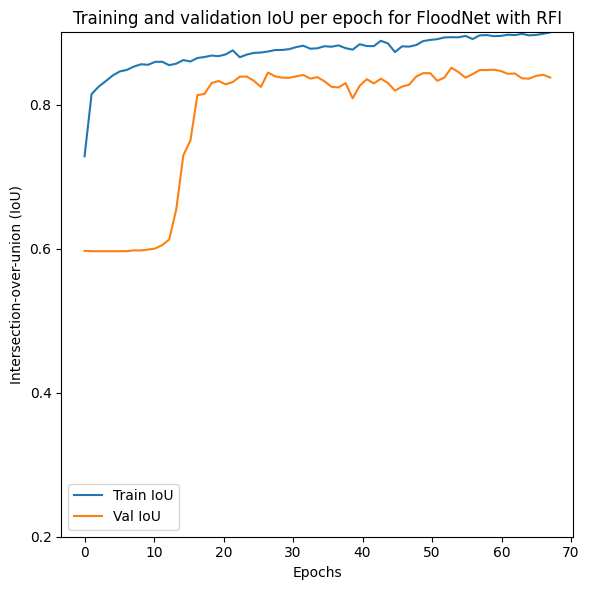

In [14]:
if not LOAD_MODEL:
  train_iou = history.history["flood_iou"]
  val_iou = history.history["val_flood_iou"]

  plt.figure(figsize=(6,6))
  plt.plot(np.linspace(0, len(train_iou), len(train_iou)), train_iou)
  plt.plot(np.linspace(0, len(val_iou),  len(val_iou)), val_iou)
  plt.title("Training and validation IoU per epoch for FloodNet with RFI")
  plt.xlabel("Epochs")
  plt.ylabel("Intersection-over-union (IoU)")
  plt.yticks(np.arange(0, max(val_iou), 0.2))
  plt.ylim(0.2, max(train_iou))
  plt.tight_layout()
  plt.legend(["Train IoU", "Val IoU"])
  # plt.savefig("/content/drive/My Drive/Dissertation/figures/FloodNet_IoU_epochs_RFI.png")
  plt.show()

# Testing model

In [ ]:
# # temp cell to process data and save it
# X_Test, Y_Test = fetch_train_test_data_from_split(DS_ROOT, "test")

# X_Test_processed = []
# for sample in tqdm(X_Test, desc="testing samples"):
#   # signal_VV, IR_dict_VV = GenerateRFISignal(sample[:, :, 0], verbose=False)
#   # signal_VH, IR_dict_VH = GenerateRFISignal(sample[:, :, 1], verbose=False)
#   # sample[:, :, 0] = sample[:, :, 0] + signal_VV
#   # sample[:, :, 1] = sample[:, :, 1] + signal_VH
#   sample = normalise_0_1_single_samples(sample, X_Train_min, X_Train_max)
#   X_Test_processed.append(sample)
# X_Test_processed = np.array(X_Test_processed)


# print(f"Preprocessing {len(Y_Test)} training samples")
# Y_Test_processed = (np.asarray(Y_Test) > 0).astype(np.float32)
# Y_Test_processed = np.array(Y_Test)

# print("Writing processed data")
# with h5py.File("/content/drive/My Drive/Dissertation/Datasets/ETCI2021_40_pct_preprocessed_Test_noRFI.h5", 'w') as f:
#   f.create_dataset('X_Test', data=X_Test_processed)
#   f.create_dataset('Y_Test', data=Y_Test_processed)
#   f.close()


In [15]:
# augment
with h5py.File("/content/drive/My Drive/Dissertation/Datasets/ETCI2021_40_pct_preprocessed_Test_RFI.h5", 'r') as f:
  X_Test = f['X_Test'][:]
  Y_Test = f['Y_Test'][:]
  f.close()

# X_Train = X_Train.numpy() # they are already np
# Y_Train = Y_Train.numpy() # they are already np

X_Test_augmented = np.concatenate([
    X_Test,
    np.flip(X_Test, axis=1),
    np.flip(X_Test, axis=2),
    np.rot90(X_Test, axes=(1,2))
], axis=0)

Y_Test_augmented = np.concatenate([
    Y_Test,
    np.flip(Y_Test, axis=1),
    np.flip(Y_Test, axis=2),
    np.rot90(Y_Test, axes=(1,2))
], axis=0)

X_Test_processed = np.ascontiguousarray(
    X_Test_augmented,
    dtype=np.float32
)

Y_Test_processed = np.ascontiguousarray(
    Y_Test_augmented,
    dtype=np.float32
)

X_Test_processed = append_ratio(X_Test_processed)

print("X:", X_Test_processed.shape)
print("Y:", Y_Test_processed.shape)


X: (240, 256, 256, 3)
Y: (240, 256, 256)


In [17]:
# inference test
import time
sample = X_Test_processed[5].copy()
sample = np.expand_dims(sample, axis=0)
all_times = []
for _ in range(10):
  start = time.time()
  _ = model.predict(sample)
  all_times.append(time.time() - start)
print(f"Avg inference: {round(np.mean(all_times) * 1e3, 3)} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Avg inference: 87.949 ms


8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 829ms/step


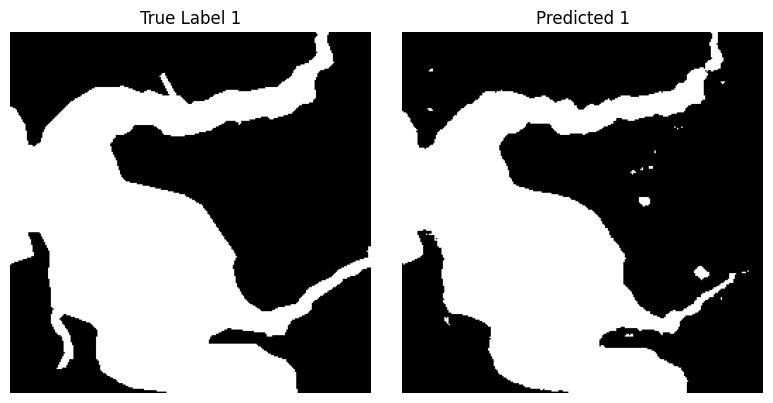

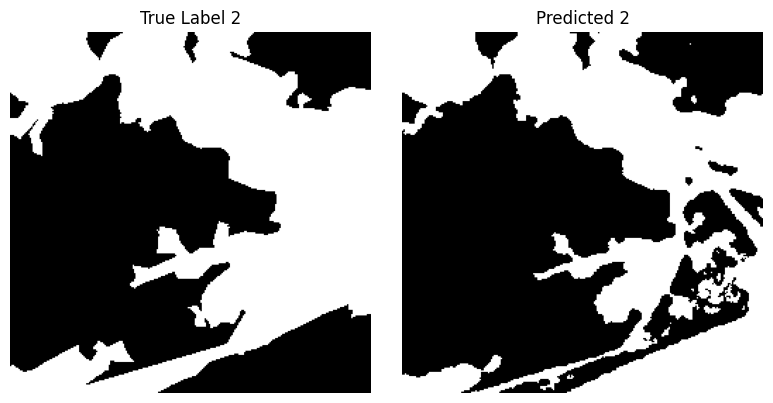

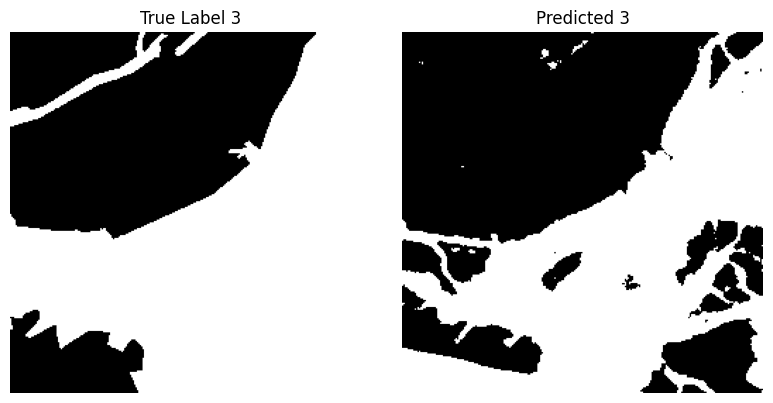

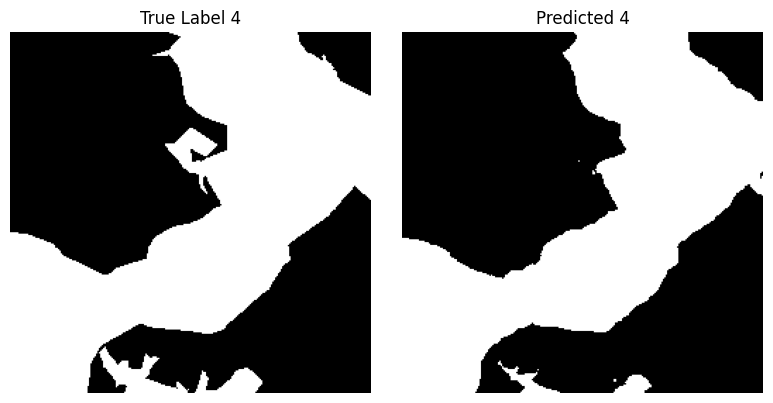

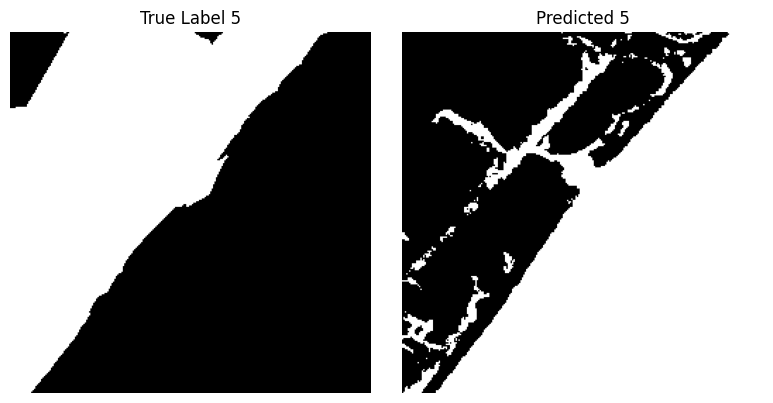

Mean Per-Image IoU:         0.6415
Mean Per-Image F1 Score:    0.7416
Mean Per-Image Precision:   0.7611
Mean Per-Image Recall:      0.7369
Mean Per-Image Dice Score:  0.7416


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score

predictions = model.predict(X_Test_processed)
# visualise some
for i in range(5):
  pred = predictions[i]
  true = Y_Test_processed[i]
  pred = (pred >= 0.5).astype(int)
  true = (true >= 0.5).astype(int)
  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  # Plot Ground Truth
  axes[0].imshow(true, cmap="gray")
  axes[0].set_title(f"True Label {i+1}")
  axes[0].axis("off")

  # Plot Prediction
  axes[1].imshow(pred, cmap="gray")
  axes[1].set_title(f"Predicted {i+1}")
  axes[1].axis("off")

  # Display this specific figure
  plt.tight_layout()
  path = f"/content/drive/My Drive/Dissertation/figures/sample_{str(i)}_floodnet_RFI.png"
  # plt.savefig(path)
  plt.show()

def dice_score(y_true, y_pred, threshold=0.5):
    y_true = np.asarray(y_true).astype(bool)
    y_pred = (np.asarray(y_pred) >= threshold)

    intersection = np.sum(y_true & y_pred)

    return (2.0 * intersection) / (
        np.sum(y_true) + np.sum(y_pred) + 1e-7
    )


# Metric evaluation
y_pred = (predictions >= 0.5).astype(int)
y_true = (Y_Test_processed >= 0.5).astype(int)

# Lists to store metrics for each image
img_ious = []
img_f1s = []
img_precisions = []
img_recalls = []
img_dices = []

# Loop through every single image in the test set
for i in range(len(X_Test_processed)):
    # Flatten just the current single image's masks
    true_img = y_true[i].flatten()
    pred_img = y_pred[i].flatten()

    # Check if there are ANY actual flood pixels or predicted flood pixels
    # This avoids 0/0 division anomalies for completely dry images
    if np.sum(true_img) == 0 and np.sum(pred_img) == 0:
        # Perfect prediction of no flood!
        iou = 1.0
        f1 = 1.0
        precision = 1.0
        recall = 1.0
    else:
        # Calculate standard binary metrics for the flood class (1)
        # zero_division=0 ensures that if it predicts no flood, it doesn't crash
        iou = jaccard_score(true_img, pred_img, pos_label=1, zero_division=0)
        f1 = f1_score(true_img, pred_img, pos_label=1, zero_division=0)
        precision = precision_score(true_img, pred_img, pos_label=1, zero_division=0)
        recall = recall_score(true_img, pred_img, pos_label=1, zero_division=0)
        dice = dice_score(true_img, pred_img)

    img_ious.append(iou)
    img_f1s.append(f1)
    img_precisions.append(precision)
    img_recalls.append(recall)
    img_dices.append(dice)

# Calculate the mean across the whole test set
print(f"Mean Per-Image IoU:         {np.mean(img_ious):.4f}")
print(f"Mean Per-Image F1 Score:    {np.mean(img_f1s):.4f}")
print(f"Mean Per-Image Precision:   {np.mean(img_precisions):.4f}")
print(f"Mean Per-Image Recall:      {np.mean(img_recalls):.4f}")
print(f"Mean Per-Image Dice Score:  {np.mean(img_dices):.4f}")


# print("Saving results")
# with h5py.File("/content/drive/My Drive/Dissertation/data/FloodNet_results_RFI.h5", 'w') as f:
#   f.create_dataset("y_pred", data=predictions)
#   f.create_dataset("y_true", data=X_Test_processed)
#   f.attrs["iou"] = float(np.mean(img_ious))
#   f.attrs["f1"] = float(np.mean(img_f1s))
#   f.attrs["precision"] = float(np.mean(img_precisions))
#   f.attrs["recall"] = float(np.mean(img_recalls))
#   f.attrs["dice"] = float(np.mean(img_dices))
#   f.close()
# print("Saved.")